In [3]:
# We use uv for faster installation
!pip install uv
!uv pip install -q autogluon.timeseries --system
!uv pip uninstall -q torchaudio torchvision torchtext --system # fix incompatible package versions on Colab

  Using cached uv-0.12.1-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached uv-0.12.1-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (22.4 MB)


### Preparing the data for AutoGluon

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [5]:
df = df.rename(columns={"date": "timestamp"})
df["item_id"] = "ETTh1"
df = df[["item_id", "timestamp", "OT"]]
df = df.rename(columns={"OT": "target"})
df.head()

,item_id,timestamp,target
0,ETTh1,2016-07-01 00:00:00,30.531000
1,ETTh1,2016-07-01 01:00:00,27.787001
2,ETTh1,2016-07-01 02:00:00,27.787001
3,ETTh1,2016-07-01 03:00:00,25.044001
4,ETTh1,2016-07-01 04:00:00,21.948000


### Import the libraries

In [6]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [7]:
from autogluon.timeseries import TimeSeriesDataFrame

data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp",
)

data.head()

target
item_id timestamp                     
ETTh1   2016-07-01 00:00:00  30.531000
        2016-07-01 01:00:00  27.787001
        2016-07-01 02:00:00  27.787001
        2016-07-01 03:00:00  25.044001
        2016-07-01 04:00:00  21.948000

### Zero Shot Inferencing

We are comparing three models:
- Chronos2
- Chronos-bolt
- Chronos-T5

In [8]:
from autogluon.timeseries import TimeSeriesPredictor

num_test_windows = 3
prediction_length = 48

train_data, test_data = data.train_test_split(
    num_test_windows * prediction_length
)

predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="target",
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        # Chronos-2 (Zero-shot)
        "Chronos2": [
            {
                "ag_args": {
                    "name_suffix": "ZeroShot",
                }
            }
        ],

        # Original Chronos models
        "Chronos": [
            {
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small",
                },
            },
            {
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall",
                },
            },
        ],
    },
    enable_ensemble=False,
    time_limit=300,
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/content/AutogluonModels/ag-20260801_084843'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.26 GB / 12.67 GB (88.8%)
Disk Space Avail:   61.34 GB / 112.64 GB (54.5%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small'},
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix': 'BoltSmall'},
                                  'model_path'

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

	-1.4038       = Validation score (-MASE)
	18.15   s     = Training runtime
	0.78    s     = Validation (prediction) runtime
Training timeseries model ChronosT5Small[autogluon__chronos-t5-small]. Training for up to 137.5s of the 275.0s of remaining time.


config.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

	-1.2638       = Validation score (-MASE)
	2.87    s     = Training runtime
	4.55    s     = Validation (prediction) runtime
Training timeseries model ChronosBoltSmall[autogluon__chronos-bolt-small]. Training for up to 267.6s of the 267.6s of remaining time.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

	-1.3218       = Validation score (-MASE)
	0.02    s     = Training runtime
	2.27    s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2ZeroShot', 'ChronosT5Small[autogluon__chronos-t5-small]', 'ChronosBoltSmall[autogluon__chronos-bolt-small]']
Total runtime: 28.66 s
Best model: ChronosT5Small[autogluon__chronos-t5-small]
Best model score: -1.2638


In [9]:
predictions = predictor.predict(train_data)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: ChronosT5Small[autogluon__chronos-t5-small]


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
ETTh1   2018-06-20 20:00:00  8.833281  8.529183  8.543664  8.666751  8.760876   
        2018-06-20 21:00:00  8.543664  8.130961  8.239568  8.326452  8.442299   
        2018-06-20 22:00:00  8.326452  7.768942  8.094760  8.159924  8.254048   
        2018-06-20 23:00:00  8.181644  7.587932  7.790663  8.036837  8.080279   
        2018-06-21 00:00:00  8.109241  7.580692  7.674817  7.797904  7.906509   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
ETTh1   2018-06-20 20:00:00  8.833281  8.905684  9.238742  9.369069  9.564560  
        2018-06-20 21:00:00  8.543664  8.601587  9.093934  9.282184  9.593522  
        2018-06-20 22:00:00  8.326452  8.456779  8.608828  8.934646  9.137376  
        2018-06-20 23:00:00  8.181644  8.254048  8.608828  8.891204  9.137376  
        2018-06-21 00:00:00  8.109241  8.326452  8.543664  8.572625  8.804318

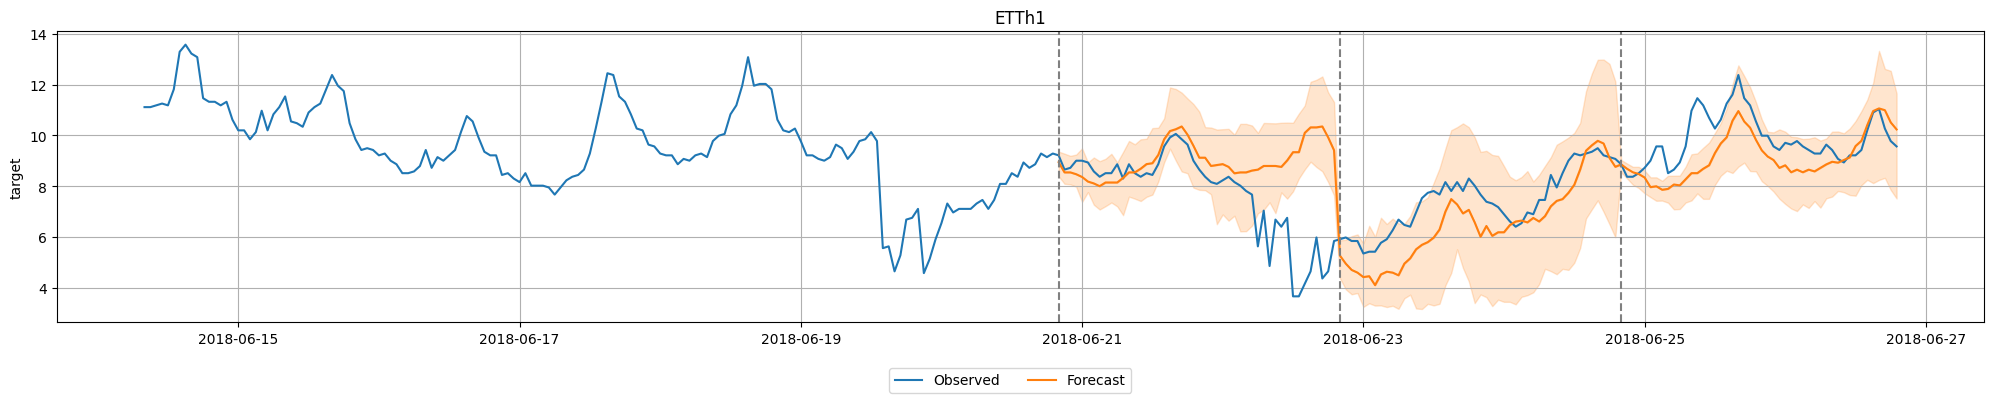

In [11]:
import matplotlib.pyplot as plt

# Generate predictions for multiple windows
predictions_per_window = predictor.backtest_predictions(test_data, num_val_windows=num_test_windows)

# Plot predictions for the first two time series
item_ids = test_data.item_ids[:2].tolist()
all_predictions = pd.concat(predictions_per_window)
predictor.plot(test_data, all_predictions, max_history_length=300, item_ids=item_ids)

# Optional: Plot the cutoff dates with dashed vertical lines
for cutoff in range(-num_test_windows * prediction_length, 0, prediction_length):
    for i, ax in enumerate(plt.gcf().axes):
        cutoff_timestamp = test_data.loc[item_ids[i]].index[cutoff]
        ax.axvline(cutoff_timestamp, color='gray', linestyle='--')
plt.show()

In [ ]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2ZeroShot,-0.418048,-1.403767,1.235240,0.097032,1.253767,1
1,ChronosBoltSmall[autogluon__chronos-bolt-small],-0.419172,-1.321752,1.139437,1.136322,0.019060,3
2,ChronosT5Small[autogluon__chronos-t5-small],-0.472804,-1.263756,1.977993,2.039878,0.019353,2


## Forecasting with covariates

In [12]:
data = TimeSeriesDataFrame.from_path(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/bull/test.parquet", id_column="id"
)
data.head()

load  airtemperature  \
item_id                timestamp                                     
Bull_education_Magaret 2016-01-01 00:00:00  0.0000             9.4   
                       2016-01-01 01:00:00  2.7908             8.9   
                       2016-01-01 02:00:00  3.7210             8.9   
                       2016-01-01 03:00:00  2.7908             8.3   
                       2016-01-01 04:00:00  9.3025             7.8   

                                            dewtemperature  sealvlpressure  
item_id                timestamp                                            
Bull_education_Magaret 2016-01-01 00:00:00             3.3     1028.699951  
                       2016-01-01 01:00:00             2.2     1028.800049  
                       2016-01-01 02:00:00             2.2     1029.599976  
                       2016-01-01 03:00:00             1.7     1029.500000  
                       2016-01-01 04:00:00             1.7     1029.599976

In [13]:
prediction_length = 24
train_data, test_data = data.train_test_split(prediction_length=prediction_length)

Sorting the dataframe index before generating the train/test split.


In [ ]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=["airtemperature", "dewtemperature", "sealvlpressure"],
    eval_metric="MASE",
).fit(
    train_data,
    hyperparameters={
        # Chronos-2 (Zero-shot)
        "Chronos2": [
            {
                "ag_args": {
                    "name_suffix": "ZeroShot",
                }
            }
        ],

        # Original Chronos models
        "Chronos": [
            {
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small",
                },
            },
            {
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall",
                },
            },
        ],
    },
    enable_ensemble=False,
    time_limit=300,
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/content/AutogluonModels/ag-20260801_074332'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 12.80/14.56 GB
Total GPU Memory:   Free: 12.80 GB, Allocated: 1.76 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.22 GB / 12.67 GB (72.7%)
Disk Space Avail:   60.26 GB / 112.64 GB (53.5%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small'},
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix': 'BoltSmall'},
                                  'model_path':

In [ ]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2ZeroShot,-0.696239,-0.817203,9.595674,8.186734,1.568277,1
1,ChronosT5Small[autogluon__chronos-t5-small],-1.051704,-1.068404,4.578785,4.673140,0.317839,2
2,ChronosBoltSmall[autogluon__chronos-bolt-small],-1.278404,-1.086471,1.191419,1.211241,0.270628,3


In [ ]:
predictor.feature_importance(test_data, model="Chronos2ZeroShot", relative_scores=True)

Computing feature importance


,importance,stdev,n,p99_low,p99_high
airtemperature,0.324308,0.000000e+00,5.0,0.324308,0.324308
dewtemperature,0.057110,7.757919e-18,5.0,0.057110,0.057110
sealvlpressure,0.038278,0.000000e+00,5.0,0.038278,0.038278


## Fine Tuning the Model

In [ ]:
predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="load",
    known_covariates_names=["airtemperature", "dewtemperature", "sealvlpressure"],
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        "Chronos2": [
            # Zero-shot model
            {"fine_tune": False, "ag_args": {"name_suffix": "ZeroShot"}},
            # Fine-tuned model
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}},
        ],

        # Original Chronos models
        "Chronos": [
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_ZeroShot",
                },
            },
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_ZeroShot",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_finetune",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_finetune",
                },
            },
        ],
    },
    time_limit=900,  # time limit in seconds
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 900s
AutoGluon will save models to '/content/AutogluonModels/ag-20260801_074652'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 12.76/14.56 GB
Total GPU Memory:   Free: 12.76 GB, Allocated: 1.80 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.15 GB / 12.67 GB (72.2%)
Disk Space Avail:   60.25 GB / 112.64 GB (53.5%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small_ZeroShot'},
                                  'fine_tune': False,
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix'

In [ ]:
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos2FineTuned,-0.695698,-0.824554,8.809470,9.500880,167.540894,2
1,Chronos2ZeroShot,-0.696239,-0.817203,9.523579,7.849560,1.458264,1
2,ChronosT5Small_finetune[autogluon__chronos-t5-...,-1.070160,-1.047530,3.341978,3.121905,286.503873,5
3,ChronosT5Small_ZeroShot[autogluon__chronos-t5-...,-1.084515,-1.062281,4.472924,4.601419,0.271105,3
4,ChronosBoltSmall_ZeroShot[autogluon__chronos-b...,-1.278404,-1.086471,1.285467,1.182546,0.230624,4
5,ChronosBoltSmall_finetune[autogluon__chronos-b...,-1.341506,-1.060191,0.296899,0.144945,286.717645,6


### Fine Tuning Without Covariates

In [ ]:
from autogluon.timeseries import TimeSeriesPredictor

num_test_windows = 3
prediction_length = 48

train_data, test_data = data.train_test_split(
    num_test_windows * prediction_length
)

predictor = TimeSeriesPredictor(
    prediction_length=prediction_length,
    target="target",
    # known_covariates_names=["airtemperature", "dewtemperature", "sealvlpressure"],
    eval_metric="MASE",
).fit(
    train_data=train_data,
    hyperparameters={
        "Chronos2": [
            # Zero-shot model
            {"fine_tune": False, "ag_args": {"name_suffix": "ZeroShot"}},
            # Fine-tuned model
            {"fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}},
        ],

        # Original Chronos models
        "Chronos": [
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_ZeroShot",
                },
            },
            {
                "fine_tune":False,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_ZeroShot",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-t5-small",
                "ag_args": {
                    "name_suffix": "T5Small_finetune",
                },
            },
            {
                "fine_tune":True,
                "model_path": "autogluon/chronos-bolt-small",
                "ag_args": {
                    "name_suffix": "BoltSmall_finetune",
                },
            },
        ],
    },
    time_limit=900,  # time limit in seconds
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 900s
AutoGluon will save models to '/content/AutogluonModels/ag-20260801_081953'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.52/14.56 GB
Total GPU Memory:   Free: 14.52 GB, Allocated: 0.05 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.90 GB / 12.67 GB (78.1%)
Disk Space Avail:   60.54 GB / 112.64 GB (53.8%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'T5Small_ZeroShot'},
                                  'fine_tune': False,
                                  'model_path': 'autogluon/chronos-t5-small'},
                                 {'ag_args': {'name_suffix'

In [ ]:
predictor.leaderboard(test_data)